In [10]:
#Intensity tester
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
import os
from tqdm import tqdm
import pandas as pd
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Images
image_dir = "../images_original"
image_files = [f for f in os.listdir(image_dir) if f.endswith(".jpg")]
print(f"Number of images: {len(image_files)}")

#Annotations
annot_path = "../annotations_original.csv"
df_annot = pd.read_csv(annot_path)
#age_dict: key = image_id, value = age
age_dict = dict(zip(df_annot["image_id"], df_annot["age"]))


Number of images: 145


In [11]:
#CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

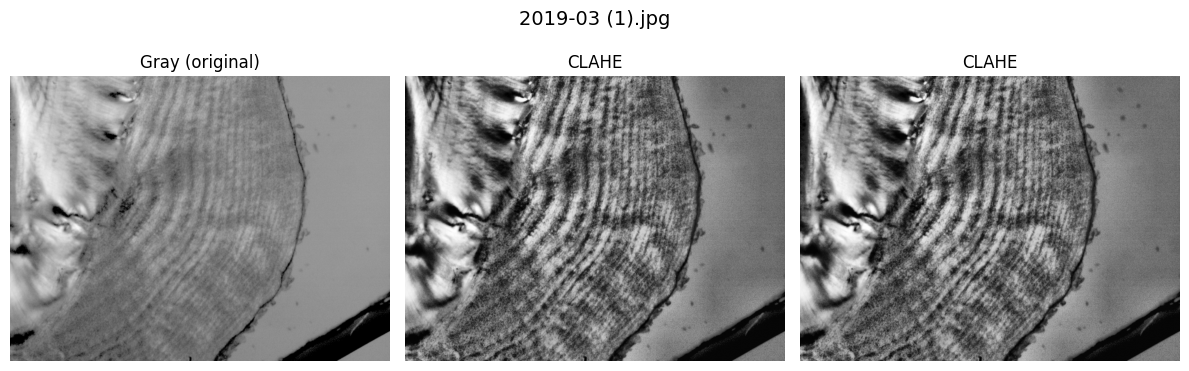

In [23]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==========================
# PARAMETERS (matchar pipeline UTAN blur)
# ==========================
img_idx = 2
clip_limit = 5.0
tile_grid_size = (8, 8)

# ==========================
# LOAD IMAGE
# ==========================
img_name = image_files[img_idx]
img_path = os.path.join(image_dir, img_name)

img = cv2.imread(img_path)
if img is None:
    raise ValueError(f"Could not load image: {img_path}")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# ==========================
# PREPROCESSING (CLAHE ONLY)
# ==========================

# CLAHE
clahe = cv2.createCLAHE(
    clipLimit=clip_limit,
    tileGridSize=tile_grid_size
)
eq = clahe.apply(gray)

# Normalize (detta är vad pipeline använder)
norm_display = cv2.normalize(
    eq, None, 0, 255, cv2.NORM_MINMAX
).astype(np.uint8)

# ==========================
# PLOT
# ==========================
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(gray, cmap="gray")
plt.title("Gray (original)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(eq, cmap="gray")
plt.title("CLAHE")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(norm_display, cmap="gray")
plt.title("CLAHE + normalize\n(used for peaks)")
plt.axis("off")

plt.suptitle(img_name, fontsize=14)
plt.tight_layout()
plt.show()


#Blur and gausian was implemented first but that introduced issues by deleting thin lines